# 08 — Unsupervised anomaly detection and environmental regimes
**Purpose:** identify unusual combinations of seasonally adjusted climate and SAR conditions, compare a sparse optical-inclusive model, and discover recurring environmental regimes.  
**Inputs:** `outputs/tables/langtang_monthly_features.csv` from notebook 06.  
**Outputs:** anomaly scores, PCA loadings, cluster diagnostics, model diagnostics, an augmented feature table, and diagnostic charts.  
**Runtime:** typically under five minutes; no Earth Engine request is required.  
**Dependencies:** completed notebook 06 and packages in `requirements.txt`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'
%pip -q install -r requirements.txt


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.5 MB/s eta 0:00:00


In [2]:
import json
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from src.anomaly_detection import run_anomaly_detection
from src.config import SETTINGS
from src.trend_analysis import load_integrated_features
from src.utils import ensure_output_directories
from src.visualization import plot_anomaly_scores, plot_environmental_regimes
ensure_output_directories()


## Fit reference-period models
The primary model prefers complete climate plus Sentinel-1 VV/VH change months. If those changes have insufficient overlap, it uses VV/VH seasonal anomalies; if SAR is unavailable, it runs a documented climate-only model. A separate multisensor model also requires Sentinel-2 snow fraction, snow-fraction change, and NDSI, and is reported only when enough complete training months exist. All models are fitted on observations before 2026, with no interpolation or event labels. Robust distance, Isolation Forest, and PCA reconstruction error are converted to empirical training-distribution percentiles and averaged. `anomaly_score` is therefore a screening score, not a probability of collapse or any other event.

In [3]:
feature_path = SETTINGS.output_tables / 'langtang_monthly_features.csv'
features = load_integrated_features(feature_path)
anomaly_results, loadings, cluster_diagnostics, model_diagnostics = (
    run_anomaly_detection(features)
)
print('Training period ends before:', SETTINGS.anomaly_training_end)
display(pd.DataFrame(model_diagnostics))


Training period ends before: 2026-01-01


,group,features,complete_months,training_months,training_end_exclusive,pca_components,pca_explained_variance,training_median,training_scale,feature_strategy,candidate_complete_training_months,requested_features,actual_features,dropped_features,drop_reason,training_rows,training_period
0,climate_sar_change,"[temp_anomaly, PDD_adjusted, precip_7d_adjuste...",113,106,2026-01-01,4,0.962908,"{'temp_anomaly': 0.3669221073805936, 'PDD_adju...","{'temp_anomaly': 0.9411309421416608, 'PDD_adju...",climate_sar_change,"{'climate_sar_change': 106, 'climate_sar_level...","[temp_anomaly, PDD_adjusted, precip_7d_adjuste...","[temp_anomaly, PDD_adjusted, precip_7d_adjuste...",[],{},106.0,before 2026-01-01 (exclusive)
1,multisensor_climate_sar_change,"[temp_anomaly, PDD_adjusted, precip_7d_adjuste...",100,93,2026-01-01,4,0.923400,"{'temp_anomaly': 0.4275936895222714, 'PDD_adju...","{'temp_anomaly': 1.0690078243465517, 'PDD_adju...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Save reproducible outputs
The augmented table preserves the original inputs and adds raw algorithm scores, empirical percentile scores, an ensemble score, the largest standardized feature, and arbitrary regime IDs. PCA loadings describe mathematical components and should not be treated as physical causes.

In [4]:
augmented_path = SETTINGS.output_tables / 'langtang_monthly_features_with_anomaly.csv'
anomaly_results.to_csv(augmented_path, index=False)
model_name = anomaly_results['anomaly_model_name'].dropna().iloc[0]
score_columns = [
    'date', 'anomaly_model_name', 'anomaly_score', 'anomaly_direction',
    'anomaly_interpretation', 'anomaly_above_reference_quantile',
    'top_contributing_feature', 'environmental_regime',
    'regime_PC1', 'regime_PC2',
]
score_columns += [
    f'{model_name}_{algorithm}_{suffix}'
    for algorithm in ('robust', 'isolation', 'pca')
    for suffix in ('raw', 'percentile')
]
anomaly_scores = anomaly_results[score_columns].copy()
anomaly_scores.to_csv(SETTINGS.output_tables / 'anomaly_scores.csv', index=False)
loadings.to_csv(SETTINGS.output_tables / 'pca_loadings.csv', index=False)
cluster_diagnostics.to_csv(
    SETTINGS.output_tables / 'cluster_diagnostics.csv', index=False
)
with (SETTINGS.output_tables / 'anomaly_model_diagnostics.json').open('w') as file:
    json.dump(model_diagnostics, file, indent=2, default=str)
print('Actual primary model:', model_name)
print('Saved:', augmented_path)


Actual primary model: climate_sar_change
Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/tables/langtang_monthly_features_with_anomaly.csv


## Rank unusual months
Higher values indicate months that look less typical relative to the pre-2026 reference distribution. Ranking is exploratory: observation quality, source coverage, the largest contributing feature, and all three component algorithms should be reviewed before interpreting any month.

In [5]:
ranked = anomaly_results.loc[
    anomaly_results['anomaly_score'].notna(),
    [
        'date', 'anomaly_model_name', 'anomaly_score',
        'anomaly_direction', 'top_contributing_feature',
        'anomaly_above_reference_quantile', 'environmental_regime',
    ],
]
display(ranked.sort_values('anomaly_score', ascending=False).head(20))
event_year_screen = ranked.loc[ranked['date'].dt.year == 2026].copy()
event_year_screen['rank_among_observed_months'] = (
    anomaly_results['anomaly_score'].rank(ascending=False, method='min')
)
display(event_year_screen)


,date,anomaly_model_name,anomaly_score,anomaly_direction,top_contributing_feature,anomaly_above_reference_quantile,environmental_regime
75,2021-10-01,climate_sar_change,0.940252,above_reference,PDD_adjusted,True,0
80,2022-03-01,climate_sar_change,0.930818,below_reference,VV_change_adjusted,True,1
39,2018-10-01,climate_sar_change,0.924528,below_reference,PDD_adjusted,True,1
63,2020-10-01,climate_sar_change,0.915094,above_reference,PDD_adjusted,True,0
106,2024-05-01,climate_sar_change,0.902516,above_reference,PDD_adjusted,True,0
111,2024-10-01,climate_sar_change,0.889937,above_reference,precip_7d_adjusted,True,1
107,2024-06-01,climate_sar_change,0.874214,above_reference,PDD_adjusted,False,0
27,2017-10-01,climate_sar_change,0.836478,above_reference,PDD_adjusted,False,0
48,2019-07-01,climate_sar_change,0.823899,above_reference,precip_7d_adjusted,False,1
77,2021-12-01,climate_sar_change,0.817610,below_reference,temp_anomaly,False,1


,date,anomaly_model_name,anomaly_score,anomaly_direction,top_contributing_feature,anomaly_above_reference_quantile,environmental_regime,rank_among_observed_months
126,2026-01-01,climate_sar_change,0.094340,above_reference,temp_anomaly,False,1,111.0
127,2026-02-01,climate_sar_change,0.188679,above_reference,VV_change_adjusted,False,1,103.0
128,2026-03-01,climate_sar_change,0.644654,below_reference,VH_change_adjusted,False,1,34.0
129,2026-04-01,climate_sar_change,0.572327,above_reference,precip_7d_adjusted,False,1,47.0
130,2026-05-01,climate_sar_change,0.584906,below_reference,PDD_adjusted,False,1,44.0
131,2026-06-01,climate_sar_change,0.729560,below_reference,PDD_adjusted,False,1,19.0
132,2026-07-01,climate_sar_change,0.427673,above_reference,PDD_adjusted,False,0,70.0


## Diagnostic figures and regimes
K-means cluster count is chosen from 2–6 using the best training-period silhouette score. Cluster numbers are arbitrary recurring states, not hazard categories. The two plotted PCA axes are a projection and do not contain all model variance.

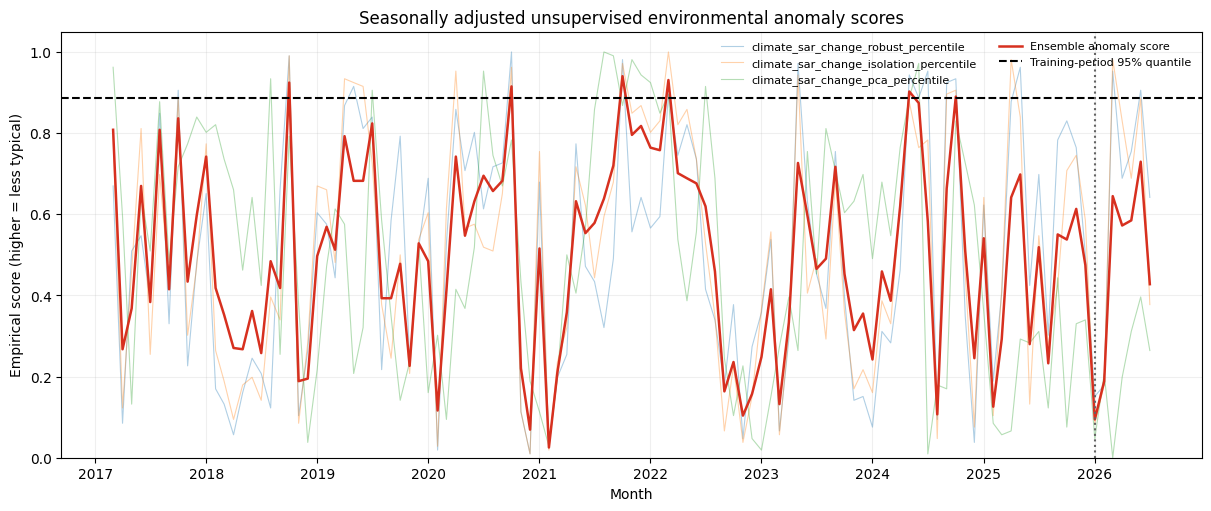

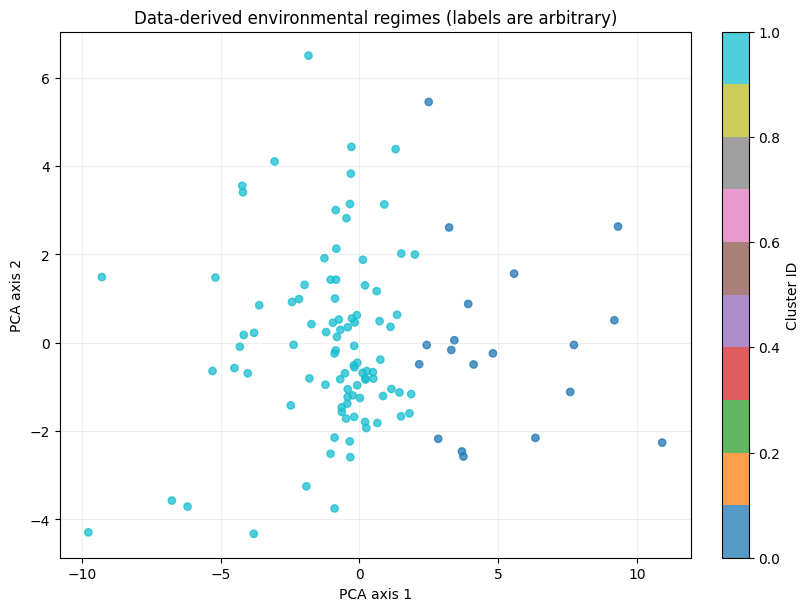

,n_clusters,silhouette_score
0,2,0.355402
1,3,0.303212
2,4,0.282934
3,5,0.267148
4,6,0.213425


,feature,PC1,PC2,PC3,PC4,group
0,temp_anomaly,0.208778,-0.180933,-0.195488,0.940097,climate_sar_change
1,PDD_adjusted,0.966203,-0.000742,0.175709,-0.179746,climate_sar_change
2,precip_7d_adjusted,-0.054696,0.789711,0.479921,0.258235,climate_sar_change
3,antecedent_precipitation_index_adjusted,0.040053,0.209922,0.165029,0.082219,climate_sar_change
4,VV_change_adjusted,-0.077316,-0.371588,0.576250,0.093841,climate_sar_change
5,VH_change_adjusted,-0.110859,-0.401839,0.584199,0.040711,climate_sar_change
6,temp_anomaly,0.143881,-0.244634,-0.173455,0.489482,multisensor_climate_sar_change
7,PDD_adjusted,0.976242,0.074688,0.119685,-0.143651,multisensor_climate_sar_change
8,precip_7d_adjusted,-0.023510,0.716546,0.277504,0.584479,multisensor_climate_sar_change
9,antecedent_precipitation_index_adjusted,0.037426,0.236900,0.147992,0.044921,multisensor_climate_sar_change


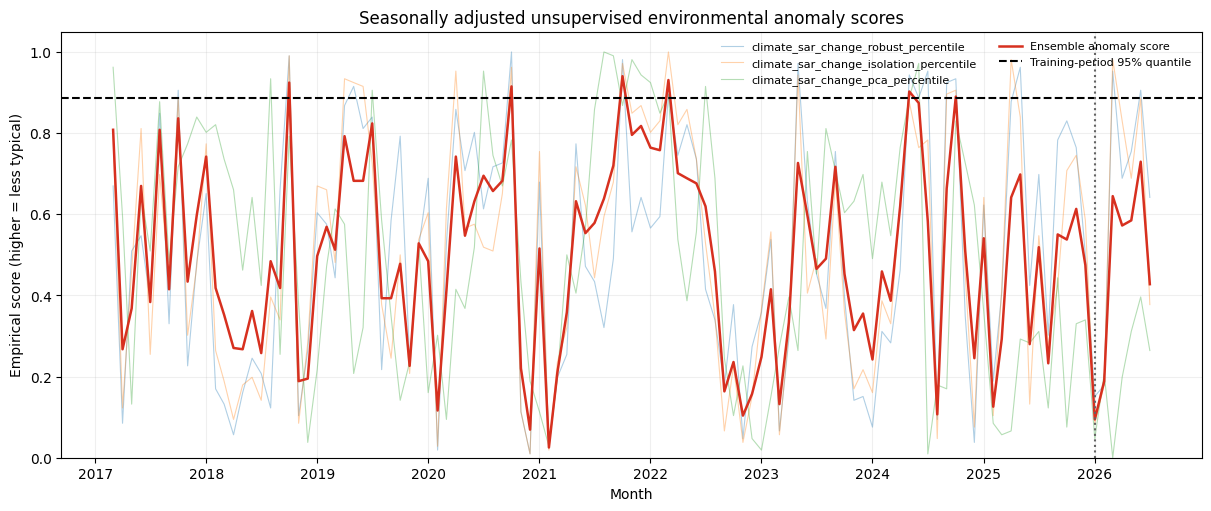

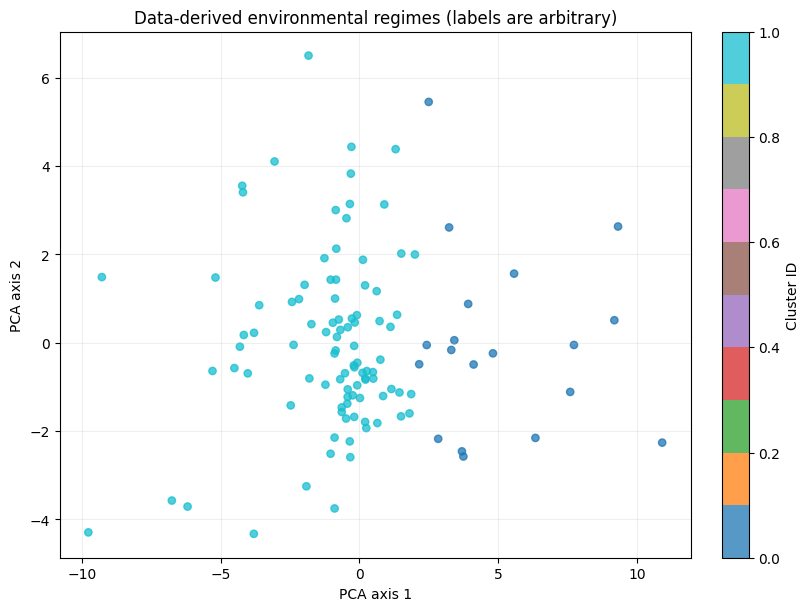

In [6]:
anomaly_figure = plot_anomaly_scores(
    anomaly_results, SETTINGS.anomaly_training_end,
    SETTINGS.anomaly_reference_quantile,
    SETTINGS.output_charts / 'anomaly_score_timeseries.png',
)
regime_figure = plot_environmental_regimes(
    anomaly_results, SETTINGS.output_charts / 'environmental_regimes_pca.png'
)
display(anomaly_figure)
display(regime_figure)
display(cluster_diagnostics)
display(loadings)


## Interpretation checkpoint
An anomalous month is only unusual under this feature set, preprocessing method, training window, and available observations. It is not evidence of instability, a collapse precursor, a causal mechanism, or predictive skill. Do not force a 2026 interpretation: compare its ranks with earlier months, confirm sensor quality and coverage, inspect the component scores and dominant feature, and seek independent spatial and field evidence.